# Imports Libraries

In [2]:
import os
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


# Create Project Structure

In [3]:
base_dir = os.getcwd()

folders = [
    "data/processed",
    "data/clients",
    "notebooks",
    "models",
    "results",
    "reports"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project structure created.")

Project structure created.


# Column Names

In [4]:
columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol',
    'fbs', 'restecg', 'thalach', 'exang',
    'oldpeak', 'slope', 'ca', 'thal', 'target'
]

# Load Dataset

# cleveland

In [5]:
df = pd.read_csv(
    "data/raw/processed.cleveland.data",
    names=columns
)

print(df.shape)

(303, 14)


In [6]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


# Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [8]:
import numpy as np

df.replace("?", np.nan, inplace=True)

df["ca"] = pd.to_numeric(df["ca"])
df["thal"] = pd.to_numeric(df["thal"])

In [9]:
df.nunique()

age          41
sex           2
cp            4
trestbps     50
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            4
thal          3
target        5
dtype: int64

In [10]:
df.target.value_counts()

target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

In [11]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

# Missing Values

In [12]:
(df == "?").sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [13]:
df.replace("?", np.nan, inplace=True)

In [14]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

# Clean data

In [15]:
df["ca"] = df["ca"].fillna(df["ca"].median())
df["thal"] = df["thal"].fillna(df["thal"].median())

In [16]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

# Convert Target

In [17]:
df["target"] = df["target"].apply(lambda x: 0 if x == 0 else 1)

In [18]:
df.target.value_counts()

target
0    164
1    139
Name: count, dtype: int64

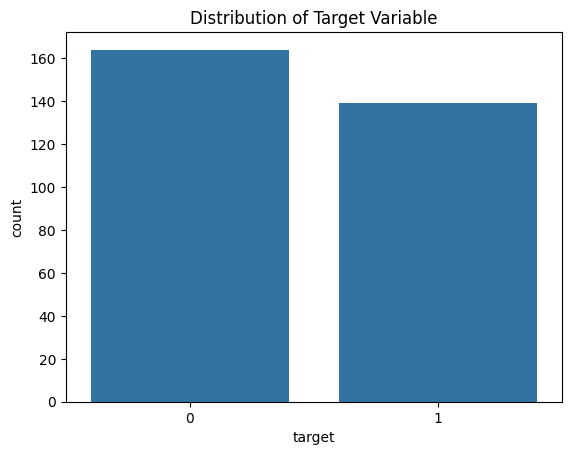

In [19]:
sns.countplot(x="target", data=df)
plt.title("Distribution of Target Variable")
plt.show()

In [20]:
df.nunique().sort_values()

sex           2
fbs           2
target        2
exang         2
slope         3
thal          3
restecg       3
cp            4
ca            4
oldpeak      40
age          41
trestbps     50
thalach      91
chol        152
dtype: int64

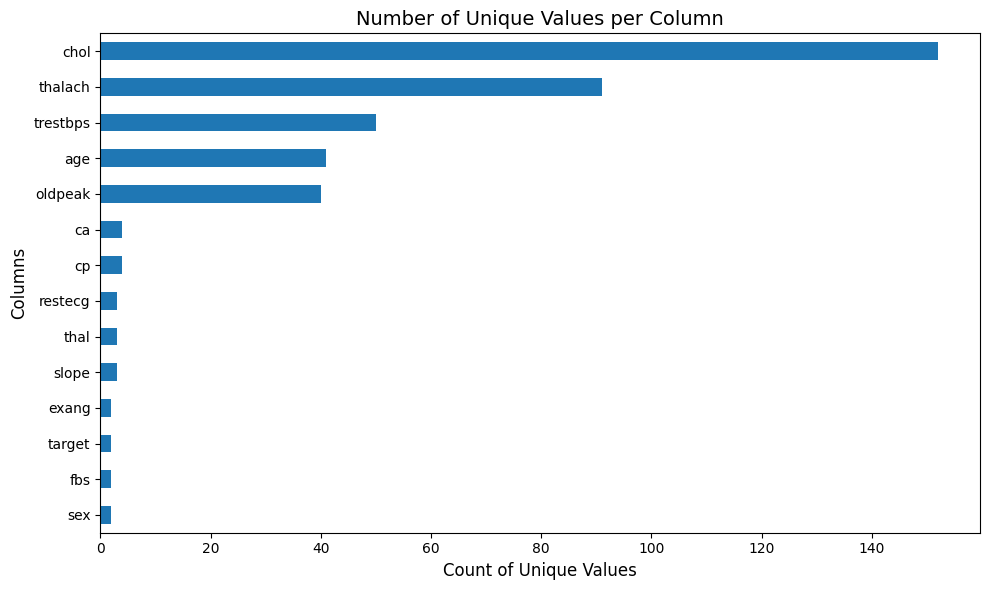

In [21]:

# Sort the unique values and plot as a horizontal bar chart
df.nunique().sort_values().plot(kind="barh", figsize=(10, 6))

# Add titles and labels
plt.title("Number of Unique Values per Column", fontsize=14)
plt.xlabel("Count of Unique Values", fontsize=12)
plt.ylabel("Columns", fontsize=12)

# Adjust layout to make sure column names aren't truncated
plt.tight_layout()
plt.show()

In [22]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


# Save Clean Dataset

In [23]:
df.to_csv(
    "data/processed/cleveland_clean.csv",
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.


# hungarian

In [27]:
df2 = pd.read_csv(
    "data/raw/processed.hungarian.data",
    names=columns
)
print(df2.shape)

df2.head()

(294, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,28,1,2,130,132,0,2,185,0,0.0,?,?,?,0
1,29,1,2,120,243,0,0,160,0,0.0,?,?,?,0
2,29,1,2,140,?,0,0,170,0,0.0,?,?,?,0
3,30,0,1,170,237,0,1,170,0,0.0,?,?,6,0
4,31,0,2,100,219,0,1,150,0,0.0,?,?,?,0


In [28]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       294 non-null    int64  
 1   sex       294 non-null    int64  
 2   cp        294 non-null    int64  
 3   trestbps  294 non-null    object 
 4   chol      294 non-null    object 
 5   fbs       294 non-null    object 
 6   restecg   294 non-null    object 
 7   thalach   294 non-null    object 
 8   exang     294 non-null    object 
 9   oldpeak   294 non-null    float64
 10  slope     294 non-null    object 
 11  ca        294 non-null    object 
 12  thal      294 non-null    object 
 13  target    294 non-null    int64  
dtypes: float64(1), int64(4), object(9)
memory usage: 32.3+ KB


In [29]:

# Replace ? with NaN
df2.replace("?", np.nan, inplace=True)

numeric_cols = [
    "age", "sex", "cp", "trestbps", "chol",
    "fbs", "restecg", "thalach", "exang",
    "oldpeak", "slope", "ca", "thal", "target"
]

for col in numeric_cols:
    df2[col] = pd.to_numeric(df2[col], errors="coerce")

In [30]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       294 non-null    int64  
 1   sex       294 non-null    int64  
 2   cp        294 non-null    int64  
 3   trestbps  293 non-null    float64
 4   chol      271 non-null    float64
 5   fbs       286 non-null    float64
 6   restecg   293 non-null    float64
 7   thalach   293 non-null    float64
 8   exang     293 non-null    float64
 9   oldpeak   294 non-null    float64
 10  slope     104 non-null    float64
 11  ca        3 non-null      float64
 12  thal      28 non-null     float64
 13  target    294 non-null    int64  
dtypes: float64(10), int64(4)
memory usage: 32.3 KB


In [31]:
df2.nunique()

age          38
sex           2
cp            4
trestbps     31
chol        153
fbs           2
restecg       3
thalach      71
exang         2
oldpeak      10
slope         3
ca            1
thal          3
target        2
dtype: int64

In [32]:
df2.target.value_counts()

target
0    188
1    106
Name: count, dtype: int64

In [33]:
df2.isnull().sum()

age           0
sex           0
cp            0
trestbps      1
chol         23
fbs           8
restecg       1
thalach       1
exang         1
oldpeak       0
slope       190
ca          291
thal        266
target        0
dtype: int64

In [35]:
# Continuous features → median
median_cols = ["trestbps", "chol", "thalach"]
for col in median_cols:
    df2[col] = df2[col].fillna(df2[col].median())
# Categorical features → mode
mode_cols = ["fbs", "restecg", "exang", "slope", "ca", "thal"]
for col in mode_cols:
    df2[col] = df2[col].fillna(df2[col].mode()[0])

In [36]:
print(df2.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [37]:
df2["target"] = df2["target"].apply(lambda x: 0 if x == 0 else 1)
df2.target.value_counts()

target
0    188
1    106
Name: count, dtype: int64

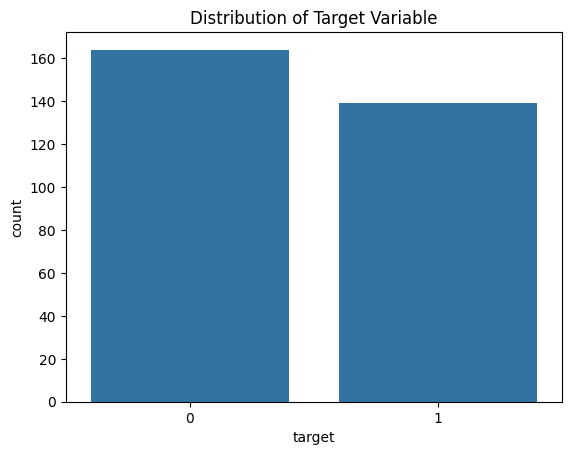

In [38]:
sns.countplot(x="target", data=df)
plt.title("Distribution of Target Variable")
plt.show()

In [39]:
df2.nunique().sort_values()

ca            1
sex           2
exang         2
fbs           2
target        2
slope         3
restecg       3
thal          3
cp            4
oldpeak      10
trestbps     31
age          38
thalach      71
chol        153
dtype: int64

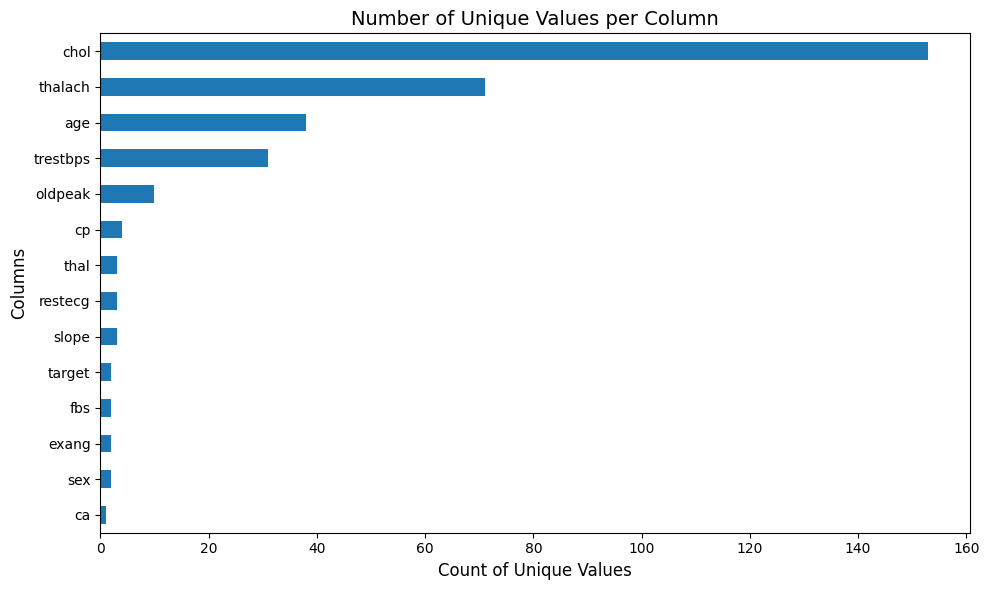

In [40]:

# Sort the unique values and plot as a horizontal bar chart
df2.nunique().sort_values().plot(kind="barh", figsize=(10, 6))

# Add titles and labels
plt.title("Number of Unique Values per Column", fontsize=14)
plt.xlabel("Count of Unique Values", fontsize=12)
plt.ylabel("Columns", fontsize=12)

# Adjust layout to make sure column names aren't truncated
plt.tight_layout()
plt.show()



In [41]:
df2.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,28,1,2,130.0,132.0,0.0,2.0,185.0,0.0,0.0,2.0,0.0,7.0,0
1,29,1,2,120.0,243.0,0.0,0.0,160.0,0.0,0.0,2.0,0.0,7.0,0
2,29,1,2,140.0,243.0,0.0,0.0,170.0,0.0,0.0,2.0,0.0,7.0,0
3,30,0,1,170.0,237.0,0.0,1.0,170.0,0.0,0.0,2.0,0.0,6.0,0
4,31,0,2,100.0,219.0,0.0,1.0,150.0,0.0,0.0,2.0,0.0,7.0,0


# sava the data

In [43]:
df2.to_csv(
    "data/processed/hungarian_clean.csv",
    index=False
)
print("Dataset saved successfully.")

Dataset saved successfully.


# switzerland

In [45]:
df3 = pd.read_csv(
    "data/raw/processed.switzerland.data",
    names=columns
)
print(df3.shape)

df3.head()

(123, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,32,1,1,95,0,?,0,127,0,.7,1,?,?,1
1,34,1,4,115,0,?,?,154,0,.2,1,?,?,1
2,35,1,4,?,0,?,0,130,1,?,?,?,7,3
3,36,1,4,110,0,?,0,125,1,1,2,?,6,1
4,38,0,4,105,0,?,0,166,0,2.8,1,?,?,2


In [25]:
import pandas as pd
import numpy as np

columns = [
    'age','sex','cp','trestbps','chol',
    'fbs','restecg','thalach','exang',
    'oldpeak','slope','ca','thal','target'
]

def preprocess_dataset(input_file, output_file):

    df = pd.read_csv(
        input_file,
        names=columns
    )

    # Replace ? with NaN
    df.replace("?", np.nan, inplace=True)

    # Convert columns
    df["ca"] = pd.to_numeric(df["ca"], errors="coerce")
    df["thal"] = pd.to_numeric(df["thal"], errors="coerce")

    # Fill missing values
    df["ca"] = df["ca"].fillna(df["ca"].median())
    df["thal"] = df["thal"].fillna(df["thal"].median())

    # Binary target
    df["target"] = df["target"].apply(
        lambda x: 0 if x == 0 else 1
    )

    # Save
    df.to_csv(output_file, index=False)

    print(f"Saved: {output_file}")
    print(f"Shape: {df.shape}")

# Process all hospitals

In [26]:
preprocess_dataset(
    "data/raw/processed.cleveland.data",
    "data/processed/cleveland_clean.csv"
)

preprocess_dataset(
    "data/raw/processed.hungarian.data",
    "data/processed/hungarian_clean.csv"
)

preprocess_dataset(
    "data/raw/processed.switzerland.data",
    "data/processed/switzerland_clean.csv"
)

preprocess_dataset(
    "data/raw/processed.va.data",
    "data/processed/va_clean.csv"
)

Saved: data/processed/cleveland_clean.csv
Shape: (303, 14)
Saved: data/processed/hungarian_clean.csv
Shape: (294, 14)
Saved: data/processed/switzerland_clean.csv
Shape: (123, 14)
Saved: data/processed/va_clean.csv
Shape: (200, 14)
